# Implicit Runge-Kutta: order, stiff decay, Newton's method and derivatives

`si.implicit(model, method, dt=..., ...)` turns a continuous-time model into the discrete map of an
implicit Runge-Kutta method: a Function with the model's own signature whose stages are found by
Newton's method inside the generated C. This notebook runs the implicit methods on four problems. A
non-stiff Van der Pol oscillator measures their orders. Prothero and Robinson's test equation at
$h\lambda = -10^4$ separates the L-stable methods from the ones that are only A-stable. Robertson's
chemical kinetics is integrated over eleven decades of time in 56 steps. The stiff Van der Pol
oscillator ($\mu = 1000$) compares simplified with full Newton, and checks the Jacobians of a step,
which come from the implicit function theorem rather than from differentiating the iterations.

| Scaly feature | Where |
| --- | --- |
| `si.implicit` with `dt=None` and `tol=` | Orders, Robertson |
| the families `gauss_legendre`, `radau_iia`, `lobatto_iiia`, `lobatto_iiic`; the named methods `backward_euler`, `implicit_midpoint`, `trapezoidal`, `sdirk2`, `sdirk3` | Orders, Stiffness |
| `si.tableau` (`.a`, `.b`, `.order`) | Orders, Stiffness |
| `si.rk4` | Stiffness |
| `newton_iters=`, `newton="simplified"` or `"full"` | Robertson, Newton's method |
| `sc.jacobian` of an implicit step | Derivatives |
| several maps called in one `sc.function` and stacked | every sweep compiles once |
| `write_module` | The generated C |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "integrators" / "stiff_implicit"

## Orders on a non-stiff problem

The model is Van der Pol's oscillator with a force $u$ and the parameter $\mu$ as inputs,

$$
\dot x_1 = x_2, \qquad \dot x_2 = \mu (1 - x_1^2)\, x_2 - x_1 + u ,
$$

here with $\mu = 1$ and $u = 0.3$ from $x = (2, 0)$. An $s$-stage method with coefficients $(A, b, c)$
finds its stages $K = (K_1, \dots, K_s)$ from

$$
G(K) = \Big(K_i - f\big(x + h \textstyle\sum_j a_{ij} K_j\big)\Big)_{i = 1..s} = 0, \qquad x^+ = x + h \sum_i b_i K_i ,
$$

and its order is $2s$ for Gauss-Legendre, $2s - 1$ for Radau IIA and $2s - 2$ for Lobatto IIIA and
IIIC. Backward Euler is Radau IIA(1), the implicit midpoint rule Gauss-Legendre(1), the trapezoidal
rule Lobatto IIIA(2); SDIRK2 and SDIRK3 are Alexander's diagonally implicit methods of orders 2 and 3.

Every map takes the step size as an input (`dt=None`) and iterates Newton's method to `tol=1e-13`,
so the iterations' error stays below the truncation error. `stiff_order_steps` calls all fifteen
maps, each at its own state, and stacks the results: the whole sweep is one compiled Function.

In [2]:
MU, U0, X0, T = 1.0, 0.3, np.array([2.0, 0.0]), 2.0
STEP_COUNTS = (4, 8, 16, 32, 64, 128)
ORDER_FLOOR = 1e-11  # errors below this are rounding and Newton's tolerance, not truncation
METHODS = [
  ("gauss_legendre", 1),
  ("gauss_legendre", 2),
  ("gauss_legendre", 3),
  ("radau_iia", 1),
  ("radau_iia", 2),
  ("radau_iia", 3),
  ("lobatto_iiia", 2),
  ("lobatto_iiia", 3),
  ("lobatto_iiic", 2),
  ("lobatto_iiic", 3),
  ("backward_euler", None),
  ("implicit_midpoint", None),
  ("trapezoidal", None),
  ("sdirk2", None),
  ("sdirk3", None),
]


def label(method, stages):
  return f"{method}{stages or ''}"


@sc.function(2, 1, (), output="xdot")
def stiff_vdp(x, u, mu):
  return sc.stack([x[1], mu * (1 - x[0] * x[0]) * x[1] - x[0] + u[0]])


ORDER_MAPS = [si.implicit(stiff_vdp, m, stages=s, dt=None, tol=1e-13, max_iter=50) for m, s in METHODS]


@sc.function((len(METHODS), 2), 1, (), (), output="xnext")
def stiff_order_steps(xs, u, mu, dt):
  return sc.stack([step(xs[i], u, mu, dt) for i, step in enumerate(ORDER_MAPS)])

In [3]:
exact = solve_ivp(lambda t, x: [x[1], MU * (1 - x[0] ** 2) * x[1] - x[0] + U0], (0, T), X0, method="DOP853", rtol=1e-13, atol=1e-14).y[:, -1]
errors = []
for n in STEP_COUNTS:
  xs = np.tile(X0, (len(METHODS), 1))
  for _ in range(n):
    xs = stiff_order_steps(xs, np.array([U0]), np.array(MU), np.array(T / n))
  errors.append(np.abs(xs - exact).max(axis=1))
order_errors = dict(zip([label(m, s) for m, s in METHODS], np.array(errors).T, strict=True))


def observed_order(err):
  """The least-squares slope of log error against log h over the three finest step sizes above the floor."""
  keep = np.flatnonzero(err > ORDER_FLOOR)[-3:]
  return float(-np.polyfit(np.log(np.array(STEP_COUNTS, dtype=float)[keep]), np.log(err[keep]), 1)[0])


orders = {name: observed_order(err) for name, err in order_errors.items()}
declared = {label(m, s): si.tableau(m, s).order for m, s in METHODS}
print(f"{'method':18s} " + " ".join(f"{f'n = {n}':>8s}" for n in STEP_COUNTS) + "   order (declared)")
for name, err in order_errors.items():
  print(f"{name:18s} " + " ".join(f"{e:8.1e}" for e in err) + f"   {orders[name]:4.2f} ({declared[name]})")

method                n = 4    n = 8   n = 16   n = 32   n = 64  n = 128   order (declared)
gauss_legendre1     1.1e-02  2.6e-03  6.4e-04  1.6e-04  4.0e-05  9.9e-06   2.00 (2)
gauss_legendre2     2.5e-04  1.3e-05  7.3e-07  4.5e-08  2.8e-09  1.7e-10   4.00 (4)
gauss_legendre3     6.2e-06  1.1e-07  1.8e-09  2.8e-11  4.4e-13  1.6e-14   5.97 (6)
radau_iia1          4.6e-01  1.6e-01  6.8e-02  3.2e-02  1.5e-02  7.6e-03   1.03 (1)
radau_iia2          1.8e-03  2.5e-04  3.4e-05  4.5e-06  5.8e-07  7.4e-08   2.97 (3)
radau_iia3          4.0e-05  1.5e-06  5.1e-08  1.7e-09  5.3e-11  1.7e-12   4.96 (5)
lobatto_iiia2       6.8e-02  1.6e-02  3.9e-03  9.7e-04  2.4e-04  6.0e-05   2.00 (2)
lobatto_iiia3       9.6e-04  6.3e-05  4.0e-06  2.5e-07  1.6e-08  9.8e-10   4.00 (4)
lobatto_iiic2       1.6e-02  3.9e-03  1.1e-03  2.9e-04  7.6e-05  1.9e-05   1.96 (2)
lobatto_iiic3       2.5e-04  1.2e-05  8.3e-07  5.8e-08  3.9e-09  2.5e-10   3.93 (4)
backward_euler      4.6e-01  1.6e-01  6.8e-02  3.2e-02  1.5e-02  7.6

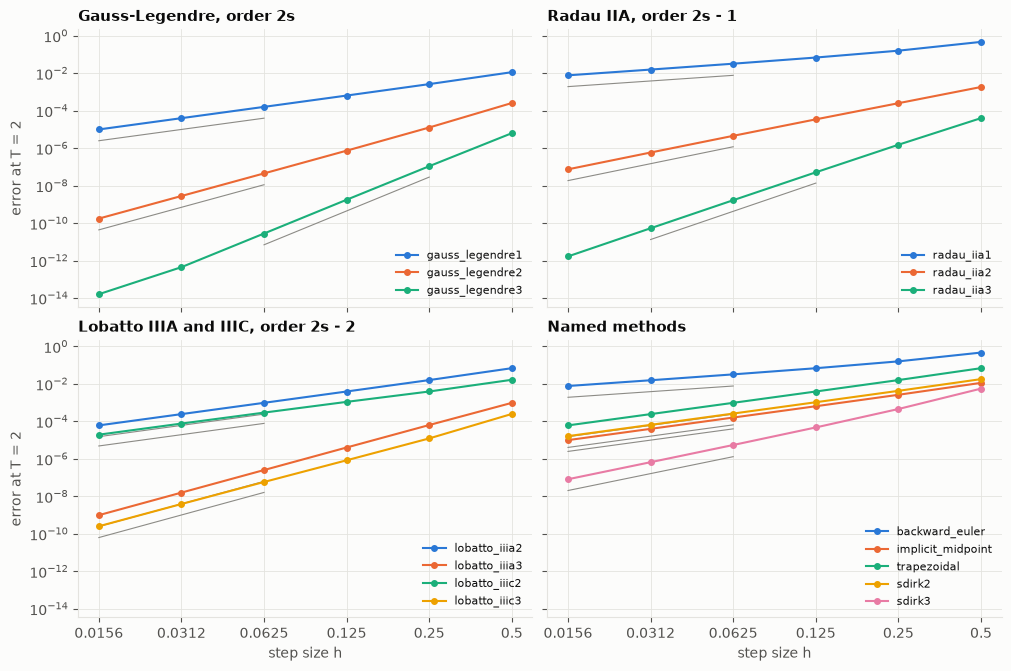

In [4]:
h = T / np.array(STEP_COUNTS)
groups = {
  "Gauss-Legendre, order 2s": ["gauss_legendre1", "gauss_legendre2", "gauss_legendre3"],
  "Radau IIA, order 2s - 1": ["radau_iia1", "radau_iia2", "radau_iia3"],
  "Lobatto IIIA and IIIC, order 2s - 2": ["lobatto_iiia2", "lobatto_iiia3", "lobatto_iiic2", "lobatto_iiic3"],
  "Named methods": ["backward_euler", "implicit_midpoint", "trapezoidal", "sdirk2", "sdirk3"],
}
fig, axes = plt.subplots(2, 2, figsize=(10, 6.6), sharex=True, sharey=True)
for ax, (title, names) in zip(axes.flat, groups.items(), strict=True):
  for name, color in zip(names, plotstyle.SERIES, strict=False):
    err = order_errors[name]
    ax.loglog(h, err, "o-", color=color, ms=4, lw=1.5, label=name)
    fit = np.flatnonzero(err > ORDER_FLOOR)[-3:]  # a thin h^p segment under the points the order is read from
    ax.loglog(h[fit], 0.25 * err[fit[-1]] * (h[fit] / h[fit[-1]]) ** declared[name], color=plotstyle.NEUTRAL, lw=0.8)
  ax.set_title(title)
  ax.set_xticks(h, [f"{v:.3g}" for v in h])
  ax.minorticks_off()
  ax.legend(fontsize=8, loc="lower right")
for ax in axes[1]:
  ax.set_xlabel("step size h")
for ax in axes[:, 0]:
  ax.set_ylabel("error at T = 2")
plt.show()

Every observed order is within 0.08 of the declared one; the largest gap is Lobatto IIIC(3) at
3.93. The aliases give the same numbers to the last digit (Radau IIA(1)
and backward Euler, Gauss-Legendre(1) and implicit midpoint, Lobatto IIIA(2) and trapezoidal). At 128
steps Gauss-Legendre(3) is at $1.6 \times 10^{-14}$, the reference's own accuracy, which is why the
order is read from the step sizes whose error is above $10^{-11}$. The thin segments under those
points have the declared slope $p$.

## Stiffness: Prothero and Robinson's equation

$$
y' = \lambda\,(y - \cos t) - \sin t, \qquad \lambda = -10^6 ,
$$

with time as a second state ($t' = 1$), so the model is autonomous. The smooth solution is
$y = \cos t$, and the error $e = y - \cos t$ obeys $e' = \lambda e$ exactly. One step of a Runge-Kutta
method multiplies it by the stability function at $z = h\lambda$,

$$
R(z) = 1 + z\, b^\top (I - zA)^{-1} \mathbf 1 .
$$

A method is A-stable when $|R(z)| \le 1$ on the whole left half-plane, and L-stable when in addition
$R(z) \to 0$ as $z \to -\infty$. At $h = 0.01$, $h\lambda = -10^4$. For RK4, $R$ is the degree-4
Taylor polynomial of $e^z$, about $z^4/24 \approx 4 \times 10^{14}$ there.

In [5]:
LAM, H_STIFF, PR_STEPS, PR_OFFSET = -1e6, 0.01, 50, 0.1
STIFF_METHODS = [
  ("radau_iia", 3),
  ("lobatto_iiic", 2),
  ("sdirk2", None),
  ("sdirk3", None),
  ("backward_euler", None),
  ("trapezoidal", None),
  ("implicit_midpoint", None),
  ("gauss_legendre", 2),
  ("gauss_legendre", 3),
]
L_STABLE = ["radau_iia3", "lobatto_iiic2", "sdirk2", "sdirk3", "backward_euler"]
A_STABLE = ["trapezoidal", "implicit_midpoint", "gauss_legendre2", "gauss_legendre3"]


@sc.function(2, output="xdot")
def stiff_prothero_robinson(x):
  return sc.stack([LAM * (x[0] - x[1].cos()) - x[1].sin(), sc.const(1.0) + 0.0 * x[0]])


# One Newton iteration solves these stage equations exactly: they are linear in the y stages, with
# the matrix simplified Newton factors, and the t stages start exact, as f(x) holds t' = 1.
STIFF_MAPS = [si.implicit(stiff_prothero_robinson, m, stages=s, dt=H_STIFF, newton_iters=1) for m, s in STIFF_METHODS]
STIFF_RK4 = si.rk4(stiff_prothero_robinson, dt=H_STIFF)


@sc.function((len(STIFF_METHODS) + 1, 2), output="xnext")
def stiff_pr_steps(xs):
  return sc.stack([*(step(xs[i]) for i, step in enumerate(STIFF_MAPS)), STIFF_RK4(xs[len(STIFF_MAPS)])])


def stability(method, stages, z):
  """R(z) = 1 + z b^T (I - z A)^{-1} 1, for an array of real z."""
  tab = si.tableau(method, stages)
  one = np.ones(tab.stages)
  return np.array([1.0 + zi * tab.b @ np.linalg.solve(np.eye(tab.stages) - zi * tab.a, one) for zi in np.atleast_1d(z)])

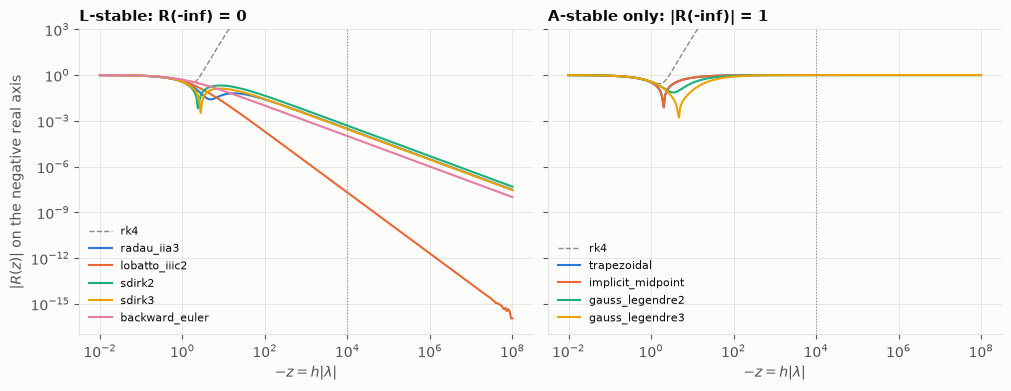

In [6]:
x_axis = np.logspace(-2, 8, 300)
methods = dict(zip([label(m, s) for m, s in STIFF_METHODS], STIFF_METHODS, strict=True))
rk4_r = np.abs(1 - x_axis + x_axis**2 / 2 - x_axis**3 / 6 + x_axis**4 / 24)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, names, title in ((axes[0], L_STABLE, "L-stable: R(-inf) = 0"), (axes[1], A_STABLE, "A-stable only: |R(-inf)| = 1")):
  ax.loglog(x_axis, rk4_r, "--", color=plotstyle.NEUTRAL, lw=1, label="rk4")
  for name, color in zip(names, plotstyle.SERIES, strict=False):
    ax.loglog(x_axis, np.abs(stability(*methods[name], -x_axis)), color=color, lw=1.5, label=name)
  ax.axvline(-H_STIFF * LAM, color=plotstyle.NEUTRAL, lw=0.8, ls=":")
  ax.set_ylim(1e-17, 1e3)
  ax.set_xlabel(r"$-z = h|\lambda|$")
  ax.set_title(title)
  ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel(r"$|R(z)|$ on the negative real axis")
plt.show()

The dotted line is Prothero and Robinson's $h|\lambda| = 10^4$. There the L-stable methods damp an
error by $3 \times 10^{-4}$ (Radau IIA(3)) to $2 \times 10^{-8}$ (Lobatto IIIC(2), whose $R$ falls as
$1/z^2$), while the A-stable ones keep $|R| = 0.998$ to $0.9996$ and RK4 amplifies it by
$4 \times 10^{14}$. The trapezoidal and implicit midpoint rules have the same $R(z)$, so their curves
coincide.

Both sweeps below run 50 steps from $y_0 = 1$ (on the solution) and from $y_0 = 1.1$ (a transient
of 0.1), every method stepping its own state in one call of `stiff_pr_steps`.

In [7]:
names = list(methods)
runs = {}
for key, y0 in (("on", 1.0), ("off", 1.0 + PR_OFFSET)):
  xs, err = np.tile([y0, 0.0], (len(STIFF_METHODS) + 1, 1)), []
  with np.errstate(over="ignore", invalid="ignore"):  # RK4 overflows by design
    for _ in range(PR_STEPS):
      xs = stiff_pr_steps(xs)
      err.append(xs[:, 0] - np.cos(xs[:, 1]))
  runs[key] = np.array(err).T  # (method, step), signed
pr_rk4_errors = np.abs(runs["on"][-1, :3])
tracking = {n: float(np.abs(runs["on"][i]).max()) for i, n in enumerate(names)}
transient = {n: runs["off"][i, :3] for i, n in enumerate(names)}
transient_end = {n: float(abs(runs["off"][i, -1])) for i, n in enumerate(names)}
r_at = {n: float(stability(*methods[n], H_STIFF * LAM)[0]) for n in names}
print(f"RK4 from y = cos t, |y - cos t| after 1, 2, 3 steps: {' '.join(f'{e:.1e}' for e in pr_rk4_errors)}")
print(f"{'method':18s} {'on cos t':>9s}   {'from y0 = 1.1: after 1, 2, 3 steps':>36s}  {'after 50':>9s}  {'R(h lambda)':>11s}")
for n in names:
  first = " ".join(f"{e:+.2e}" for e in transient[n])
  print(f"{n:18s} {tracking[n]:9.1e}   {first:>36s}  {transient_end[n]:9.1e}  {r_at[n]:+11.2e}")

RK4 from y = cos t, |y - cos t| after 1, 2, 3 steps: 1.0e+06 4.3e+20 1.8e+35
method              on cos t     from y0 = 1.1: after 1, 2, 3 steps   after 50  R(h lambda)
radau_iia3           1.2e-14          +2.99e-05 +8.97e-09 +2.70e-12    1.1e-14    +2.99e-04
lobatto_iiic2        5.0e-09          -3.00e-09 -5.00e-09 -5.00e-09    4.4e-09    +2.00e-08
sdirk2               3.5e-09          -4.82e-05 +2.68e-08 +3.52e-09    3.1e-09    -4.82e-04
sdirk3               2.1e-09          -2.87e-05 +1.03e-08 +2.08e-09    1.8e-09    -2.87e-04
backward_euler       5.0e-09          +9.99e-06 -4.00e-09 -5.00e-09    4.4e-09    +1.00e-04
trapezoidal          4.0e-12          -1.00e-01 +9.99e-02 -9.99e-02    9.8e-02    -1.00e+00
implicit_midpoint    2.5e-05          -9.99e-02 +9.99e-02 -9.99e-02    9.8e-02    -1.00e+00
gauss_legendre2      3.3e-07          +9.99e-02 +9.98e-02 +9.96e-02    9.4e-02    +9.99e-01
gauss_legendre3      2.1e-11          -9.98e-02 +9.95e-02 -9.93e-02    8.9e-02    -9.98e-01


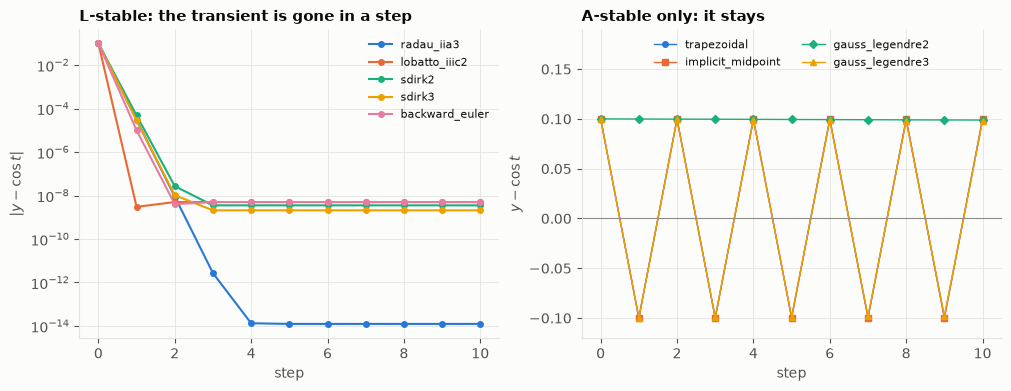

In [8]:
steps = np.arange(11)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for name, color in zip(L_STABLE, plotstyle.SERIES, strict=False):
  i = names.index(name)
  axes[0].semilogy(steps, np.abs(np.r_[PR_OFFSET, runs["off"][i, :10]]), "o-", color=color, ms=4, lw=1.5, label=name)
axes[0].set_title("L-stable: the transient is gone in a step")
axes[0].set_ylabel(r"$|y - \cos t|$")
for name, color, marker in zip(A_STABLE, plotstyle.SERIES, "osD^", strict=False):
  i = names.index(name)
  axes[1].plot(steps, np.r_[PR_OFFSET, runs["off"][i, :10]], marker + "-", color=color, ms=4, lw=1, label=name)
axes[1].axhline(0, color=plotstyle.NEUTRAL, lw=0.8)
axes[1].set_title("A-stable only: it stays")
axes[1].set_ylabel(r"$y - \cos t$")
axes[1].set_ylim(-0.12, 0.19)
axes[0].legend(fontsize=8, loc="upper right")
axes[1].legend(fontsize=8, loc="upper center", ncol=2)
for ax in axes:
  ax.set_xlabel("step")
plt.show()

Started on $\cos t$, every implicit method stays within $2.5 \times 10^{-5}$ of it. The stiffly
accurate ones, whose step is their last stage (Radau IIA, Lobatto IIIC, SDIRK, backward Euler,
trapezoidal), stay within $5 \times 10^{-9}$; the implicit midpoint rule is the worst. RK4's error
grows from $10^6$ to $1.8 \times 10^{35}$ in three steps.

Started at $y_0 = 1.1$, the first step leaves $0.1\,R(h\lambda)$ to within the method's own error on
$\cos t$: $3.0 \times 10^{-5}$ for Radau IIA(3), $-4.8 \times 10^{-5}$ for SDIRK2. Within three steps
the L-stable methods are back at their own error. The trapezoidal rule, the implicit midpoint rule
and Gauss-Legendre(3) flip the transient's sign every step ($R(-\infty) = -1$), and Gauss-Legendre(2)
carries it with the same sign ($R(-\infty) = (-1)^s = +1$); after 50 steps it is still 0.089 to 0.098.

## Robertson's chemical kinetics

Three species react at rates eleven orders of magnitude apart:

$$
\begin{aligned}
y_1' &= -0.04\, y_1 + 10^4\, y_2 y_3, \\
y_2' &= 0.04\, y_1 - 10^4\, y_2 y_3 - 3 \times 10^7\, y_2^2, \\
y_3' &= 3 \times 10^7\, y_2^2 ,
\end{aligned}
$$

from $y = (1, 0, 0)$. The right-hand sides sum to zero, so $y_1 + y_2 + y_3 = 1$. A Runge-Kutta
method keeps every such linear invariant $e^\top f = 0$: each stage has $e^\top K_i = 0$, and so does
each simplified Newton correction, since $e^\top J = 0$. Radau IIA(3) steps from $10^{-6}$ to
$10^5$ s on a geometric grid of five steps per decade, with the step size an input, against
`solve_ivp` with `method="Radau"`, `rtol=1e-10`, `atol=1e-14`.

In [9]:
PER_DECADE, T_FIRST, T_LAST = 5, 1e-6, 1e5
RATES = (0.04, 1e4, 3e7)


@sc.function(3, output="xdot")
def stiff_robertson(y):
  r1, r2, r3 = RATES[0] * y[0], RATES[1] * y[1] * y[2], RATES[2] * y[1] * y[1]
  return sc.stack([-r1 + r2, r1 - r2 - r3, r3])


ROBERTSON_STEP = si.implicit(stiff_robertson, "radau_iia", stages=3, dt=None, tol=1e-12, max_iter=50)


def robertson_np(t, y):
  r1, r2, r3 = RATES[0] * y[0], RATES[1] * y[1] * y[2], RATES[2] * y[1] ** 2
  return [-r1 + r2, r1 - r2 - r3, r3]


def robertson_jac(t, y):
  k1, k2, k3 = RATES
  return np.array([[-k1, k2 * y[2], k2 * y[1]], [k1, -k2 * y[2] - 2 * k3 * y[1], -k2 * y[1]], [0.0, 2 * k3 * y[1], 0.0]])


decades = round(np.log10(T_LAST / T_FIRST))
times = np.concatenate([[0.0], np.logspace(np.log10(T_FIRST), np.log10(T_LAST), decades * PER_DECADE + 1)])
ys, h_lambda = [np.array([1.0, 0.0, 0.0])], []
for t0, t1 in zip(times[:-1], times[1:], strict=True):
  h_lambda.append((t1 - t0) * np.abs(np.linalg.eigvals(robertson_jac(t0, ys[-1]))).max())
  ys.append(ROBERTSON_STEP(ys[-1], np.array(t1 - t0)))
ys, h_lambda = np.array(ys), np.array(h_lambda)
ref = solve_ivp(robertson_np, (0, T_LAST), [1.0, 0.0, 0.0], method="Radau", rtol=1e-10, atol=1e-14, jac=robertson_jac, t_eval=times[1:]).y.T
rel = np.abs(ys[1:] - ref) / np.abs(ref)
checks = PER_DECADE * np.arange(2, decades + 1)  # every decade from 1e-4 s, where y3 is above the reference's atol
robertson_rel_error = rel[checks].max(axis=0)
late = times[1:] >= 1e-4
robertson_conservation = float(np.abs(ys.sum(axis=1) - 1.0).max())
print(f"{times.size - 1} steps, the longest {np.diff(times).max():.2e} s; h |lambda_max| up to {h_lambda.max():.1e}")
print(
  f"largest relative error at every decade from 1e-4 s: y1 {robertson_rel_error[0]:.1e}, y2 {robertson_rel_error[1]:.1e}, y3 {robertson_rel_error[2]:.1e}"
)
print(f"largest relative error at any step from 1e-4 s:      y1 {rel[late, 0].max():.1e}, y2 {rel[late, 1].max():.1e}, y3 {rel[late, 2].max():.1e}")
print(f"|y1 + y2 + y3 - 1| <= {robertson_conservation:.1e}")

56 steps, the longest 3.69e+04 s; h |lambda_max| up to 3.6e+08
largest relative error at every decade from 1e-4 s: y1 4.6e-06, y2 4.7e-06, y3 1.6e-06
largest relative error at any step from 1e-4 s:      y1 5.0e-06, y2 6.2e-05, y3 3.5e-05
|y1 + y2 + y3 - 1| <= 2.2e-16


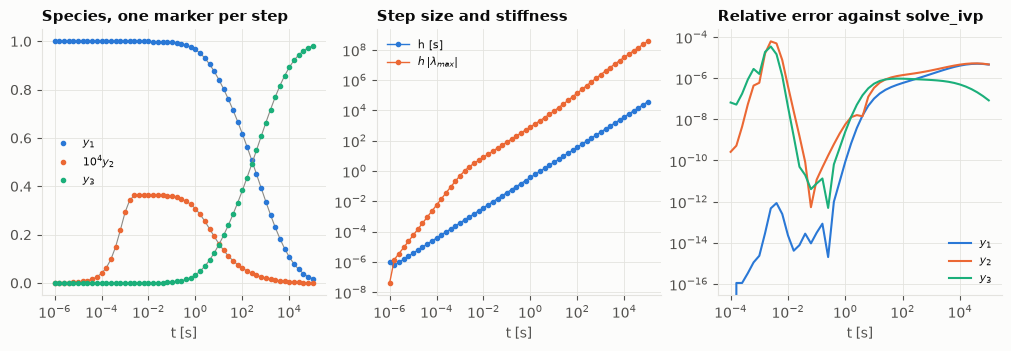

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for k, (scale, name, color) in enumerate(((1, "$y_1$", plotstyle.BLUE), (1e4, r"$10^4 y_2$", plotstyle.ORANGE), (1, "$y_3$", plotstyle.AQUA))):
  axes[0].semilogx(times[1:], scale * ref[:, k], color=plotstyle.NEUTRAL, lw=0.8)
  axes[0].semilogx(times[1:], scale * ys[1:, k], "o", color=color, ms=3, label=name)
axes[0].set_title("Species, one marker per step")
axes[0].set_xlabel("t [s]")
axes[0].legend(fontsize=8)
axes[1].loglog(times[1:], np.diff(times), "o-", color=plotstyle.BLUE, ms=3, lw=1, label="h [s]")
axes[1].loglog(times[1:], h_lambda, "o-", color=plotstyle.ORANGE, ms=3, lw=1, label=r"$h\,|\lambda_{max}|$")
axes[1].set_title("Step size and stiffness")
axes[1].set_xlabel("t [s]")
axes[1].legend(fontsize=8)
for k, color in enumerate((plotstyle.BLUE, plotstyle.ORANGE, plotstyle.AQUA)):
  axes[2].loglog(times[1:][late], rel[late, k], color=color, lw=1.5, label=f"$y_{k + 1}$")
axes[2].set_title("Relative error against solve_ivp")
axes[2].set_xlabel("t [s]")
axes[2].legend(fontsize=8, loc="lower right")
plt.show()

56 steps cover eleven decades; the longest is $3.7 \times 10^4$ s, and $h$ times the largest
eigenvalue of the model's Jacobian reaches $3.6 \times 10^8$. At every decade from $10^{-4}$ s the
relative error is below $4.7 \times 10^{-6}$ for every species. Between them it peaks at
$6 \times 10^{-5}$ in $y_2$ and $4 \times 10^{-5}$ in $y_3$ near $3 \times 10^{-3}$ s, where $y_2$
settles onto its quasi-steady value, and $y_1$ is within $10^{-12}$ until about 0.3 s. The sum
$y_1 + y_2 + y_3$ is 1 to $2.2 \times 10^{-16}$.

The step above iterates to a tolerance. With the default of a fixed three simplified Newton
iterations, the same grid goes wrong: the matrix is factored at the start of a step, and when a
step of tens of seconds meets the fast mode, three iterations with that matrix are not enough.
Three full iterations, which refactor at every iterate, are.

In [11]:
FIXED = [
  si.implicit(stiff_robertson, "radau_iia", stages=3, dt=None, name="stiff_robertson_default"),
  si.implicit(stiff_robertson, "radau_iia", stages=3, dt=None, newton="full", name="stiff_robertson_full3"),
]


@sc.function((2, 3), (), output="xnext")
def stiff_robertson_fixed(ys, dt):
  return sc.stack([step(ys[i], dt) for i, step in enumerate(FIXED)])


fixed, first_bad = [np.tile([1.0, 0.0, 0.0], (2, 1))], [None, None]
with np.errstate(invalid="ignore", over="ignore"):
  for j, (t0, t1) in enumerate(zip(times[:-1], times[1:], strict=True)):
    fixed.append(stiff_robertson_fixed(fixed[-1], np.array(t1 - t0)))
    for i in range(2):
      if first_bad[i] is None and not (np.all(np.isfinite(fixed[-1][i])) and fixed[-1][i].min() > -1e-6 and fixed[-1][i].max() < 1 + 1e-6):
        first_bad[i] = t1
fixed = np.array(fixed)
full3_gap = float(np.abs((fixed[:, 1] - ys) / np.maximum(np.abs(ys), 1e-300)).max())
print(f"3 simplified iterations: first leaves [0, 1] at t = {first_bad[0]:.3g} s, y(1e5 s) = {fixed[-1, 0]}")
print(f"3 full iterations:       never leaves it; largest relative gap to the tolerance run {full3_gap:.1e}")

3 simplified iterations: first leaves [0, 1] at t = 63.1 s, y(1e5 s) = [nan nan nan]
3 full iterations:       never leaves it; largest relative gap to the tolerance run 5.1e-07


The default step leaves the physical range at $t = 63$ s and ends in NaN; three full iterations
follow the tolerance run to a relative $5 \times 10^{-7}$ throughout. For a stiff model at steps
this long, give simplified Newton more iterations, use `newton="full"`, or iterate to `tol=`.

## Newton's method: a fixed number of iterations or a tolerance

`newton_iters=k` runs exactly $k$ iterations, the same work at every call, which is what a
controller with a deadline needs; `tol=` iterates in a `while_loop` until the stage residual is
below the tolerance. Simplified Newton solves

$$
\big(I - h A \otimes J(x)\big)\, \Delta K = -G(K)
$$

with $J(x)$ the model's Jacobian at the start of the step, factored once. With $A = T \Lambda T^{-1}$
the system splits by the eigenvalues of $A$, as in RADAU5: for Radau IIA(3), one system of the
state's size for the real eigenvalue and one of twice it for the complex pair. Full Newton
refactors the exact stage Jacobian $I - h\,[a_{ij} J(Y_i)]$ at every iteration. The comparison is
on the stiff oscillator, $\mu = 1000$, from $x = (1.5, -0.3)$ with $h = 0.05$, against the step
iterated to `tol=1e-14`.

In [12]:
MU_STIFF, X_NEWTON, DT_NEWTON = 1000.0, np.array([1.5, -0.3]), 0.05
SIMPLIFIED_ITERS, FULL_ITERS = 6, 4
NEWTON_MAPS = [
  *(si.implicit(stiff_vdp, "radau_iia", stages=3, dt=None, newton_iters=k, name=f"stiff_vdp_simplified{k}") for k in range(1, SIMPLIFIED_ITERS + 1)),
  *(
    si.implicit(stiff_vdp, "radau_iia", stages=3, dt=None, newton_iters=k, newton="full", name=f"stiff_vdp_full{k}") for k in range(1, FULL_ITERS + 1)
  ),
  si.implicit(stiff_vdp, "radau_iia", stages=3, dt=None, tol=1e-14, max_iter=100, name="stiff_vdp_simplified_tol"),
  si.implicit(stiff_vdp, "radau_iia", stages=3, dt=None, tol=1e-14, max_iter=100, newton="full", name="stiff_vdp_full_tol"),
]


@sc.function(2, 1, (), (), output="xnext")
def stiff_newton_steps(x, u, mu, dt):
  return sc.stack([step(x, u, mu, dt) for step in NEWTON_MAPS])


steps_k = stiff_newton_steps(X_NEWTON, np.array([0.0]), np.array(MU_STIFF), np.array(DT_NEWTON))
gaps = np.abs(steps_k - steps_k[-1]).max(axis=1)
simplified, full, tol_gap = gaps[:SIMPLIFIED_ITERS], gaps[SIMPLIFIED_ITERS : SIMPLIFIED_ITERS + FULL_ITERS], float(gaps[-2])
print("k           " + " ".join(f"{k:8d}" for k in range(1, SIMPLIFIED_ITERS + 1)))
print("simplified  " + " ".join(f"{e:8.1e}" for e in simplified))
print("full        " + " ".join(f"{e:8.1e}" for e in full))
print(f"simplified and full Newton to tol = 1e-14 differ by {tol_gap:.1e}")

k                  1        2        3        4        5        6
simplified   6.6e-01  2.3e-02  1.1e-04  4.0e-07  2.8e-09  5.0e-11
full         3.4e-01  5.6e-03  7.0e-07  6.0e-15
simplified and full Newton to tol = 1e-14 differ by 7.8e-17


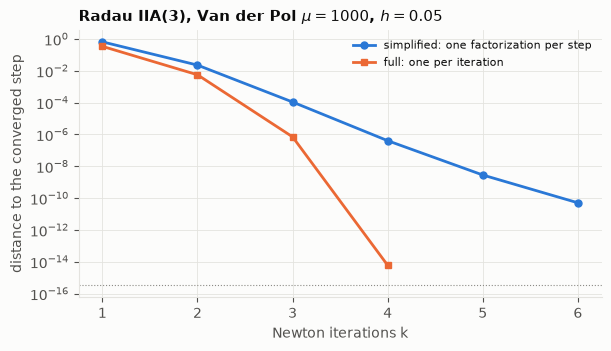

In [13]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.semilogy(np.arange(1, SIMPLIFIED_ITERS + 1), simplified, "o-", color=plotstyle.BLUE, label="simplified: one factorization per step")
ax.semilogy(np.arange(1, FULL_ITERS + 1), full, "s-", color=plotstyle.ORANGE, label="full: one per iteration")
ax.axhline(2.2e-16 * np.abs(steps_k[-1]).max(), color=plotstyle.NEUTRAL, lw=0.8, ls=":")
ax.set_xlabel("Newton iterations k")
ax.set_ylabel("distance to the converged step")
ax.set_title(r"Radau IIA(3), Van der Pol $\mu = 1000$, $h = 0.05$")
ax.legend(fontsize=8)
plt.show()

Simplified Newton converges linearly, gaining between 1.5 and 2.4 digits an iteration
($6.6 \times 10^{-1}$, $2.3 \times 10^{-2}$, $1.1 \times 10^{-4}$, $4.0 \times 10^{-7}$, ...); full
Newton doubles its digits and is at rounding ($6 \times 10^{-15}$) after four. Both, run to the
tolerance, agree to $8 \times 10^{-17}$. Full Newton costs a factorization of the whole
$6 \times 6$ stage system per iteration instead of one $2 \times 2$ and one $4 \times 4$ per step,
and its fixed-iteration maps are larger C: each iteration is unrolled.

## Derivatives by the implicit function theorem

`sc.jacobian` of the step does not differentiate the Newton iterations. At the stages $K$ the
iterations reached, the stage equations $G(K; x, u) = 0$ give

$$
\frac{\partial K}{\partial (x, u)} = -G_K^{-1}\, \big[\, G_x \;\; G_u \,\big], \qquad
\frac{\partial x^+}{\partial (x, u)} = \big[\, I \;\; 0 \,\big] + h\,(b^\top \otimes I)\, \frac{\partial K}{\partial (x, u)} ,
$$

one factorization of $G_K$ for all directions. The Jacobian is therefore that of the converged
step, evaluated where the iterations stopped. `stiff_radau_step` is the step a controller would run,
Radau IIA(3) with a fixed three simplified iterations at $h = 0.05$ on the stiff oscillator,
returning the step and both Jacobians; `stiff_radau_many` is the same step with twenty iterations.

In [14]:
DT_CONTROL, NEWTON_CONTROL, NEWTON_MANY = 0.05, 3, 20
X_JAC, U_JAC = np.array([2.0, -0.01]), np.array([0.5])
CONTROL_STEP = si.implicit(stiff_vdp, "radau_iia", stages=3, dt=DT_CONTROL, newton_iters=NEWTON_CONTROL, name="stiff_vdp_radau3_control")
MANY_STEP = si.implicit(stiff_vdp, "radau_iia", stages=3, dt=DT_CONTROL, newton_iters=NEWTON_MANY, name="stiff_vdp_radau3_many")


@sc.function(2, 1, (), output=sc.G("xnext", "jac_xnext_x", "jac_xnext_u"))
def stiff_radau_step(x, u, mu):
  xnext = CONTROL_STEP(x, u, mu)
  return xnext, sc.jacobian(xnext, x), sc.jacobian(xnext, u)


@sc.function(2, 1, (), output=sc.G("xnext", "jac_xnext_x", "jac_xnext_u"))
def stiff_radau_many(x, u, mu):
  xnext = MANY_STEP(x, u, mu)
  return xnext, sc.jacobian(xnext, x), sc.jacobian(xnext, u)


def central_differences(fn, args, k, eps):
  """Columns of d fn(...)[0] / d args[k]."""
  cols = []
  for i in range(args[k].size):
    plus, minus = [a.copy() for a in args], [a.copy() for a in args]
    plus[k][i] += eps
    minus[k][i] -= eps
    cols.append((fn(*plus)[0] - fn(*minus)[0]) / (2 * eps))
  return np.stack(cols, axis=1)


args = [X_JAC, U_JAC, np.array(MU_STIFF)]
xnext, jac_x, jac_u = stiff_radau_step(*args)
xmany, many_x, many_u = stiff_radau_many(*args)
EPS = 1e-4  # the Jacobian in u is only 3e-4, so a smaller step would leave rounding as the largest error
fd_x, fd_u = central_differences(stiff_radau_many, args, 0, EPS), central_differences(stiff_radau_many, args, 1, EPS)
control_newton_error = float(np.abs(xnext - xmany).max())
jac_x_fd_error = float(np.abs(jac_x - fd_x).max() / np.abs(fd_x).max())
jac_u_fd_error = float(np.abs(jac_u - fd_u).max() / np.abs(fd_u).max())
jac_many_gap = float(max(np.abs(jac_x - many_x).max(), np.abs(jac_u - many_u).max()))
print("jac_xnext_x =", jac_x.round(8).tolist(), " jac_xnext_u =", jac_u.ravel().round(8).tolist())
print(f"three iterations against twenty: step {control_newton_error:.1e}, Jacobians {jac_many_gap:.1e}")
print(f"against central differences of the converged step: {jac_x_fd_error:.1e} in x, {jac_u_fd_error:.1e} in u (relative)")

jac_xnext_x = [[1.00002064, 0.00032739], [0.00052776, 0.01785196]]  jac_xnext_u = [1.656e-05, 0.0003274]
three iterations against twenty: step 1.9e-11, Jacobians 2.4e-11
against central differences of the converged step: 2.8e-11 in x, 3.8e-10 in u (relative)


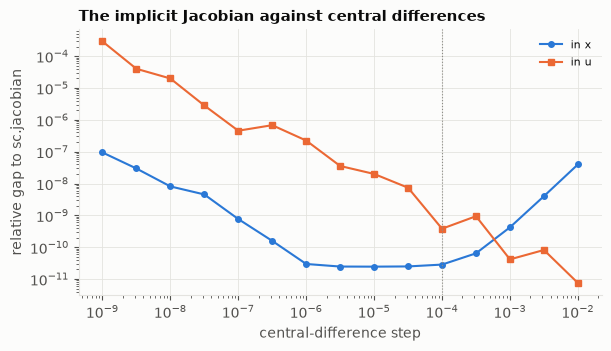

In [15]:
eps_axis = np.logspace(-9, -2, 15)
fd_err = np.array(
  [
    [
      np.abs(jac_x - central_differences(stiff_radau_many, args, 0, e)).max() / np.abs(jac_x).max(),
      np.abs(jac_u - central_differences(stiff_radau_many, args, 1, e)).max() / np.abs(jac_u).max(),
    ]
    for e in eps_axis
  ]
)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.loglog(eps_axis, fd_err[:, 0], "o-", color=plotstyle.BLUE, ms=4, lw=1.5, label="in x")
ax.loglog(eps_axis, fd_err[:, 1], "s-", color=plotstyle.ORANGE, ms=4, lw=1.5, label="in u")
ax.axvline(EPS, color=plotstyle.NEUTRAL, lw=0.8, ls=":")
ax.set_xlabel("central-difference step")
ax.set_ylabel("relative gap to sc.jacobian")
ax.set_title("The implicit Jacobian against central differences")
ax.legend(fontsize=8)
plt.show()

Near the slow manifold three iterations already put the step within $1.9 \times 10^{-11}$ of the
converged one, and its Jacobians within $2.4 \times 10^{-11}$ of the converged step's. Central
differences agree to $2.8 \times 10^{-11}$ in $x$ and $3.8 \times 10^{-10}$ in $u$ at the dotted step
$10^{-4}$. The curves show the usual trade: rounding error, falling as $1/\epsilon$, on the left,
and in $x$ truncation error, growing as $\epsilon^2$, on the right. In $u$ the rounding error is
larger relative to a Jacobian of only $3 \times 10^{-4}$, and truncation stays below it up to
$\epsilon = 10^{-2}$.

## Checks

In [16]:
for name, order in orders.items():
  assert abs(order - declared[name]) < 0.2, name
assert pr_rk4_errors[2] > 1e30  # explicit RK4 at h lambda = -1e4
assert all(error < 3e-4 for error in tracking.values())
assert tracking["radau_iia3"] < 1e-12 and tracking["trapezoidal"] < 1e-10
for name, first in transient.items():
  # The transient's first step is the stability function at h lambda, up to the method's error on cos t.
  assert abs(first[0] - 0.1 * r_at[name]) < (3e-4 if name == "implicit_midpoint" else 1e-7), name
for name in L_STABLE:  # the transient is gone
  assert abs(transient[name][0]) < 5e-4 and transient_end[name] < 5e-8, name
for name in A_STABLE:  # |R(-inf)| = 1
  assert transient_end[name] > 0.05 and np.abs(transient[name]).min() > 0.09, name
for name in ("trapezoidal", "implicit_midpoint", "gauss_legendre3"):
  assert np.all(np.diff(np.sign(transient[name])) != 0), name  # R(-inf) = -1
assert np.all(np.sign(transient["gauss_legendre2"]) > 0)  # R(-inf) = (-1)^s = +1
assert robertson_rel_error.max() < 5e-5 and robertson_conservation < 1e-14
assert h_lambda.max() > 1e8
assert first_bad[0] is not None and first_bad[1] is None and full3_gap < 1e-6  # the default fixed step fails there, full Newton does not
assert full[3] < 1e-13 and simplified[3] > 1e-8  # full Newton converges faster than simplified
assert np.all(simplified[1:] / simplified[:-1] < 0.1) and simplified[-1] < 5e-10
assert tol_gap < 1e-13
assert jac_x_fd_error < 3e-10 and jac_u_fd_error < 4e-9
assert jac_many_gap < 3e-10 and control_newton_error < 2e-10
print("all 17 checks passed")

all 17 checks passed


## The generated C

`stiff_radau_step` is one C function: the model, the three simplified Newton iterations with the
$2 \times 2$ and $4 \times 4$ factorizations, the step, and the implicit-function-theorem Jacobians,
all straight-line code at this size.

In [17]:
module = write_module(stiff_radau_step, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB, workspace {module.workspace_size} doubles")
print(next(line for line in module.header.splitlines() if line.startswith("int stiff_radau_step(")))

stiff_radau_step.c: 2271 lines, 90 kB, workspace 0 doubles
int stiff_radau_step(const double** arg, double** res, int* iw, double* w, int mem);
